In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage 

In [3]:
# 1. create some data 
data = np.array([[1,2], [1,4],[1,0],[10,2],[10,4],[10,0],[5,1],[6,3],[5,0],[7,2]])

In [4]:
# 2. Create Linkage 
linked = linkage(data, 'ward') # 'ward' reduct distance for clusters

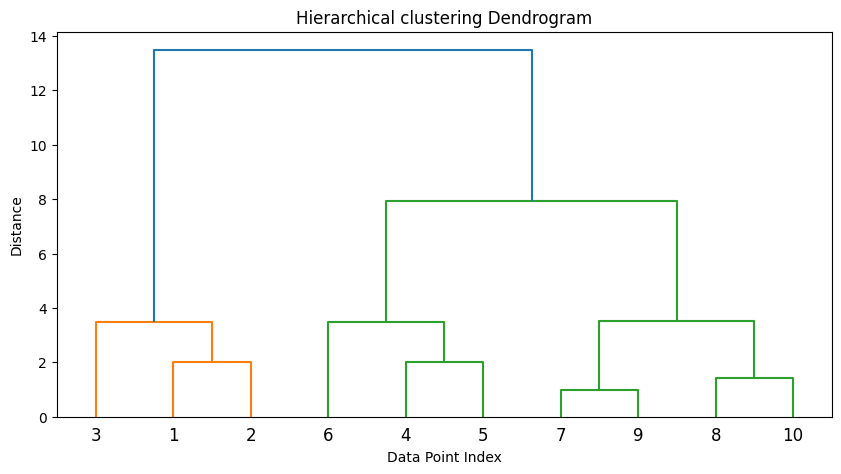

In [5]:
# 3. Dendrogram 
plt.figure(figsize=(10,5))
dendrogram(linked, labels=range(1,11))
plt.title("Hierarchical clustering Dendrogram")
plt.xlabel("Data Point Index")
plt.ylabel("Distance")
plt.show()

In [6]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(linked,t=3, criterion="maxclust") # t means number of clusters, 
print(clusters)

[1 1 1 2 2 2 3 3 3 3]


In [7]:
"""
Exmaple: Planet classification/Clustering based on Temperature and Gravity
Group 1: Mars
Group 2: Jupiter
"""

planets_data = np.array([
    [-150, 3.7], # Planet1: Mars 
    [-140, 3.9], # Planet2 
    [-130, 3.5], # Planet3
    [400, 24.8], # planet 4: Jupiter
    [450, 26.5], # planet 5
    [380, 23.4],  # planet 6  
    [-141.96, 3.74], # planet 7
    [413.59, 25.16], # planet 8
    [389.26, 24.02],# planet 9
    [-138.30, 3.81] # planet 10
])

In [8]:
# 2. Create Linkage 
linked = linkage(planets_data, 'ward') # 'ward' reduct distance for clusters

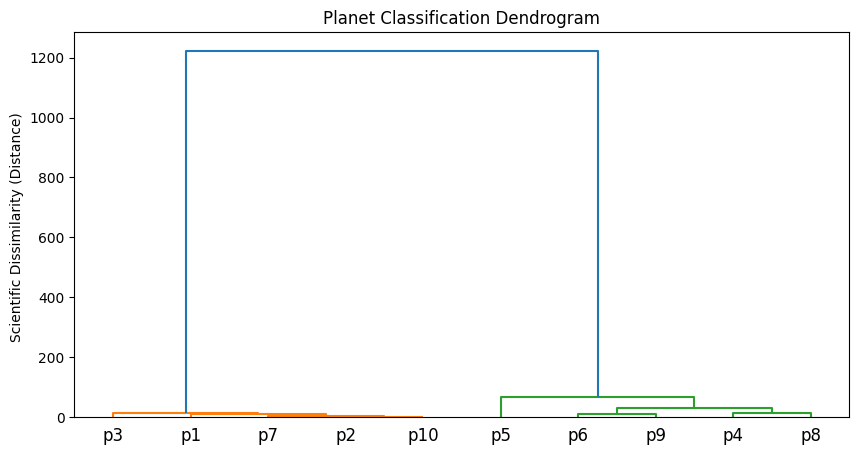

In [9]:
# 3. Dendrogram 
plt.figure(figsize=(10,5))
dendrogram(linked, labels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'])
plt.title("Planet Classification Dendrogram")
plt.ylabel("Scientific Dissimilarity (Distance) ")
plt.show()

In [10]:
planet_clusters = fcluster(linked, t=2, criterion="maxclust") # t means number of clusters, 
print(planet_clusters) # [1 1 1 2 2 2 1 2 2 1]

clusters_name = {
    1: "Mars",
    2: "Jypiter"
}

print("Planet Cluster:")
for i, p_type in enumerate(planet_clusters):
    group_name = clusters_name.get(p_type,f"Group{p_type}")
    print(f"Planet {i+1} belongs to Group {group_name}")

[1 1 1 2 2 2 1 2 2 1]
Planet Cluster:
Planet 1 belongs to Group Mars
Planet 2 belongs to Group Mars
Planet 3 belongs to Group Mars
Planet 4 belongs to Group Jypiter
Planet 5 belongs to Group Jypiter
Planet 6 belongs to Group Jypiter
Planet 7 belongs to Group Mars
Planet 8 belongs to Group Jypiter
Planet 9 belongs to Group Jypiter
Planet 10 belongs to Group Mars


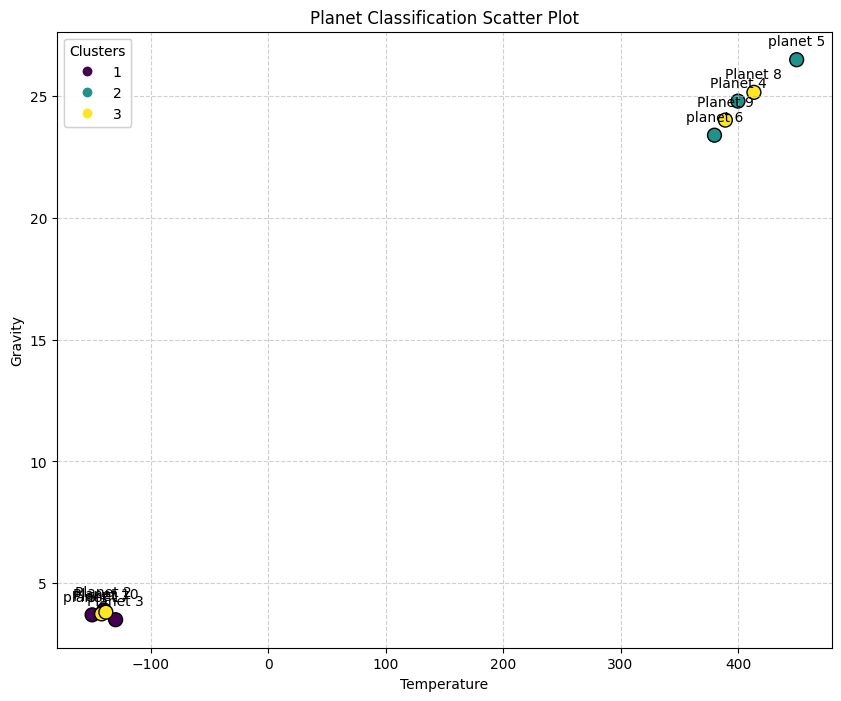

In [14]:
# Scatter plot 
labels = ["planet 1","Planet 2","Planet 3","Planet 4", "planet 5","planet 6","Planet 7", "Planet 8", "Planet 9", "Planet 10"]
plt.figure(figsize=(10,8))
scatter = plt.scatter(planets_data[:,0], planets_data[:,1], c=clusters, cmap='viridis', s=100,edgecolors='black')

for i, txt in enumerate(labels):
    plt.annotate(txt,(planets_data[i,0],planets_data[i,1]), textcoords="offset points", xytext=(0,10), ha="center")

plt.title("Planet Classification Scatter Plot")
plt.xlabel("Temperature")
plt.ylabel("Gravity")
plt.grid(True, linestyle='--', alpha=0.6)

legend1=plt.legend(*scatter.legend_elements(), title= "Clusters")
plt.gca().add_artist(legend1)
plt.show()